# Optional Lab: 逻辑回归

在这个未评分的实验中，你将：
- 探索 Sigmoid 函数（也称为逻辑函数）。
- 探索逻辑回归；它使用 Sigmoid 函数。

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from plt_one_addpt_onclick import plt_one_addpt_onclick
from lab_utils_common import draw_vthresh
plt.style.use('./deeplearning.mplstyle')

## Sigmoid函数或逻辑函数
<img align="left" src="../work/images/C1_W3_LogisticRegression_left.png"     style=" width:300px; padding: 10px; " >正如讲座视频中所讨论的，对于分类任务，我们可以从使用线性回归模型开始，

$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, 根据$x$预测$y$。
- 然而，由于我们的输出变量$y$要么是 0 要么是 1，所以我们希望分类模型的预测值在 0 到 1 之间。
- 这可以通过使用“sigmoid 函数”来实现，该函数将所有输入值映射到 0 到 1 之间的值。


让我们实现 Sigmoid 函数并亲自看看。

## 逻辑回归中 Sigmoid 函数公式
逻辑回归中 Sigmoid 函数公式如下：

$$ g(z) = \frac{1}{1+e^{-z}}  \tag{1}  $$

在逻辑回归的情况下，$z$（sigmoid 函数的输入）是线性回归模型的输出。
 - 对于单个示例，$z$是标量。
 - 对于多个示例，$z$可能是一个由$m$个值组成的向量，每个示例对应一个值。
 - sigmoid 函数的实现应涵盖这两种可能的输入格式。
让我们用 Python 实现这个。

NumPy 有一个名为 [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) 的函数, 它提供了一种方便的方法来计算输入数组（`z`）中所有元素的指数（$e^{z}$）。

它也可以接受单个数字作为输入，如下所示。

In [2]:
# Input is an array. 
input_array = np.array([1,2,3])
exp_array = np.exp(input_array)

print("Input to exp:", input_array)
print("Output of exp:", exp_array)

# Input is a single number
input_val = 1  
exp_val = np.exp(input_val)

print("Input to exp:", input_val)
print("Output of exp:", exp_val)

Input to exp: [1 2 3]
Output of exp: [ 2.72  7.39 20.09]
Input to exp: 1
Output of exp: 2.718281828459045


`sigmoid`函数在 Python 中的实现如下面的单元格所示。

In [3]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """

    g = 1/(1+np.exp(-z))
   
    return g

让我们看看这个函数对于不同的`z`值的输出是什么。

In [4]:
# Generate an array of evenly spaced values between -10 and 10
z_tmp = np.arange(-10,11)

# Use the function implemented above to get the sigmoid values
y = sigmoid(z_tmp)

# Code for pretty printing the two arrays next to each other
np.set_printoptions(precision=3) 
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


左侧列中的值是`z`，右侧列中的值是`sigmoid(z)`。如你所见，输入到 sigmoid 函数的值范围从 -10 到 10，输出值范围从 0 到 1。

现在，让我们尝试使用`matplotlib`库绘制这个函数。

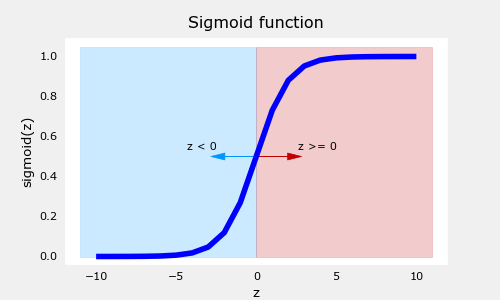

In [5]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax,0)

如你所见，当 `z` 趋向于很大的负值时，Sigmoid函数趋近于 0；当 `z` 趋向于很大的正值时，Sigmoid函数趋近于 1。

## 逻辑回归
<img align="left" src="../work/images/C1_W3_LogisticRegression_right.png"     style=" width:300px; padding: 10px; " > 

逻辑回归模型将 Sigmoid 函数应用于常见的线性回归模型，如下所示：

$$
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b ) \tag{2}
$$

其中

$$
g(z) = \frac{1}{1+e^{-z}}\tag{3}
$$


  
让我们将逻辑回归应用于肿瘤分类的分类数据示例。

首先，加载示例和参数的初始值。
  


In [6]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

w_in = np.zeros((1))
b_in = 0

尝试以下步骤：
- 点击“运行逻辑回归”以找到给定训练数据的最佳逻辑回归模型。
    - 注意，所得模型与数据非常匹配。
    - 注意，橙色线是上面的“$z$”或$\mathbf{w} \cdot \mathbf{x}^{(i)} + b$。它与线性回归模型中的线不匹配。
通过应用阈值进一步改善这些结果。
- 勾选“切换 0.5 阈值”框以显示应用阈值时的预测。
    - 这些预测看起来不错。预测与数据匹配。
    - 现在，在大肿瘤尺寸范围（接近 10）中添加更多数据点，并重新运行线性回归。
    - 与线性回归模型不同，此模型继续做出正确的预测。

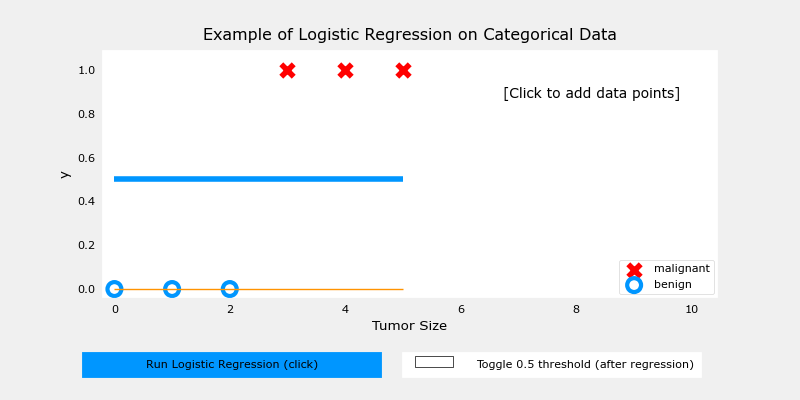

In [7]:
plt.close('all') 
addpt = plt_one_addpt_onclick( x_train,y_train, w_in, b_in, logistic=True)

## 恭喜！
你已经探索了逻辑回归中 Sigmoid 函数的使用。